# EDA

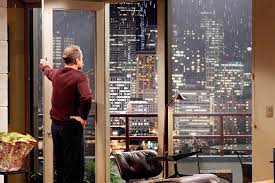

In [ ]:
import warnings

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
plt.style.use('bmh')

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()



In [ ]:
#pd.set_option("display.float_format", lambda x: "%.3f" % x) 
#pd.set_option("display.float_format", lambda x: "${:,.2f}".format(x))

In [90]:
#Extracting the data from data folder
import pandas as pd
import psycopg2

import os
from dotenv import load_dotenv

load_dotenv()

DATABASE = os.getenv("DATABASE")
USER_DB = os.getenv("USER_DB")
PASSWORD = os.getenv("PASSWORD")
HOST = os.getenv("HOST")
PORT = os.getenv("PORT")

In [91]:
conn = psycopg2.connect(
    database=DATABASE, user=USER_DB, password=PASSWORD, host=HOST, port=PORT
)

In [92]:
cur = conn.cursor()

In [93]:
# import the data into a pandas dataframe
query_string = "SELECT * FROM eda.king_county_house_details as d left join eda.king_county_house_sales as s on s.house_id=d.id"
df = pd.read_sql(query_string, conn)

In [94]:
conn.close()

In [95]:
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id
0,7129300520,3.000,1.000,1180.000,5650.000,1.000,NaN,0.000,3,7,...,0.000,98178,47.511,-122.257,1340.000,5650.000,2014-10-13,221900.000,7129300520,1
1,6414100192,3.000,2.250,2570.000,7242.000,2.000,0.000,0.000,3,7,...,19910.000,98125,47.721,-122.319,1690.000,7639.000,2014-12-09,538000.000,6414100192,2
2,5631500400,2.000,1.000,770.000,10000.000,1.000,0.000,0.000,3,6,...,NaN,98028,47.738,-122.233,2720.000,8062.000,2015-02-25,180000.000,5631500400,3
3,2487200875,4.000,3.000,1960.000,5000.000,1.000,0.000,0.000,5,7,...,0.000,98136,47.521,-122.393,1360.000,5000.000,2014-12-09,604000.000,2487200875,4
4,1954400510,3.000,2.000,1680.000,8080.000,1.000,0.000,0.000,3,8,...,0.000,98074,47.617,-122.045,1800.000,7503.000,2015-02-18,510000.000,1954400510,5


In [81]:
df['date'] = pd.to_datetime(df['date'], format='%Y-%m-%d')

In [82]:
type(df['date'][0])

pandas.Timestamp

In [ ]:
df = df.astype({ "yr_renovated": "Int64"})

df["zipcode"] = df["zipcode"].astype(str)

df["condition"] = df["condition"].astype("category")

df["grade"] = df["grade"].astype("category")

df["waterfront"] = df["waterfront"].astype("Int64")

df["bedrooms"] = df["bedrooms"].astype("Int64")

df["sqft_living"] = df["sqft_living"].astype("Int64")

df["sqft_lot"] = df["sqft_lot"].astype("Int64")

df["view"] = df["view"].astype("Int64")

In [96]:
pd.reset_option("display.float_format")

In [97]:
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,7129300520,1
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,6414100192,2
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,5631500400,3
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,2487200875,4
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,1954400510,5


### Fixing data types

We adjusted several columns from their default numeric types because their values don't represent quantities to calculate with they represent categories, flags, or identifiers:

- **`zipcode`** → `str`: a zip code is an identifier, not a number to average or sum.
- **`condition`** and **`grade`** → `category`: both are ordinal rating scales (e.g. overall condition, King County's grading system), not continuous measurements.
- **`view`** → `category`: represents the quality of the view on a fixed scale, not a quantity.
- **`waterfront`** → `Int64`: 
- **`yr_renovated`** → kept as `Int64` (nullable integer): still numeric since it's a year, but uses the nullable type to preserve any missing values. Note that `0` in this column means "never renovated," not year zero — this should be accounted for separately (e.g. a `was_renovated` flag) before using `yr_renovated` in any statistics or plots.

In [98]:
df.dtypes

id                 int64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above       float64
sqft_basement    float64
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15    float64
sqft_lot15       float64
date              object
price            float64
house_id           int64
id                 int64
dtype: object

In [102]:
df.head()

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,7129300520,1
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,6414100192,2
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,5631500400,3
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,2487200875,4
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,1954400510,5


In [71]:
# import missingno
import missingno as msno

In [72]:
# display number of missing values per column
df.isna().sum()

id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
date                0
price               0
house_id            0
id                  0
dtype: int64

<Axes: >

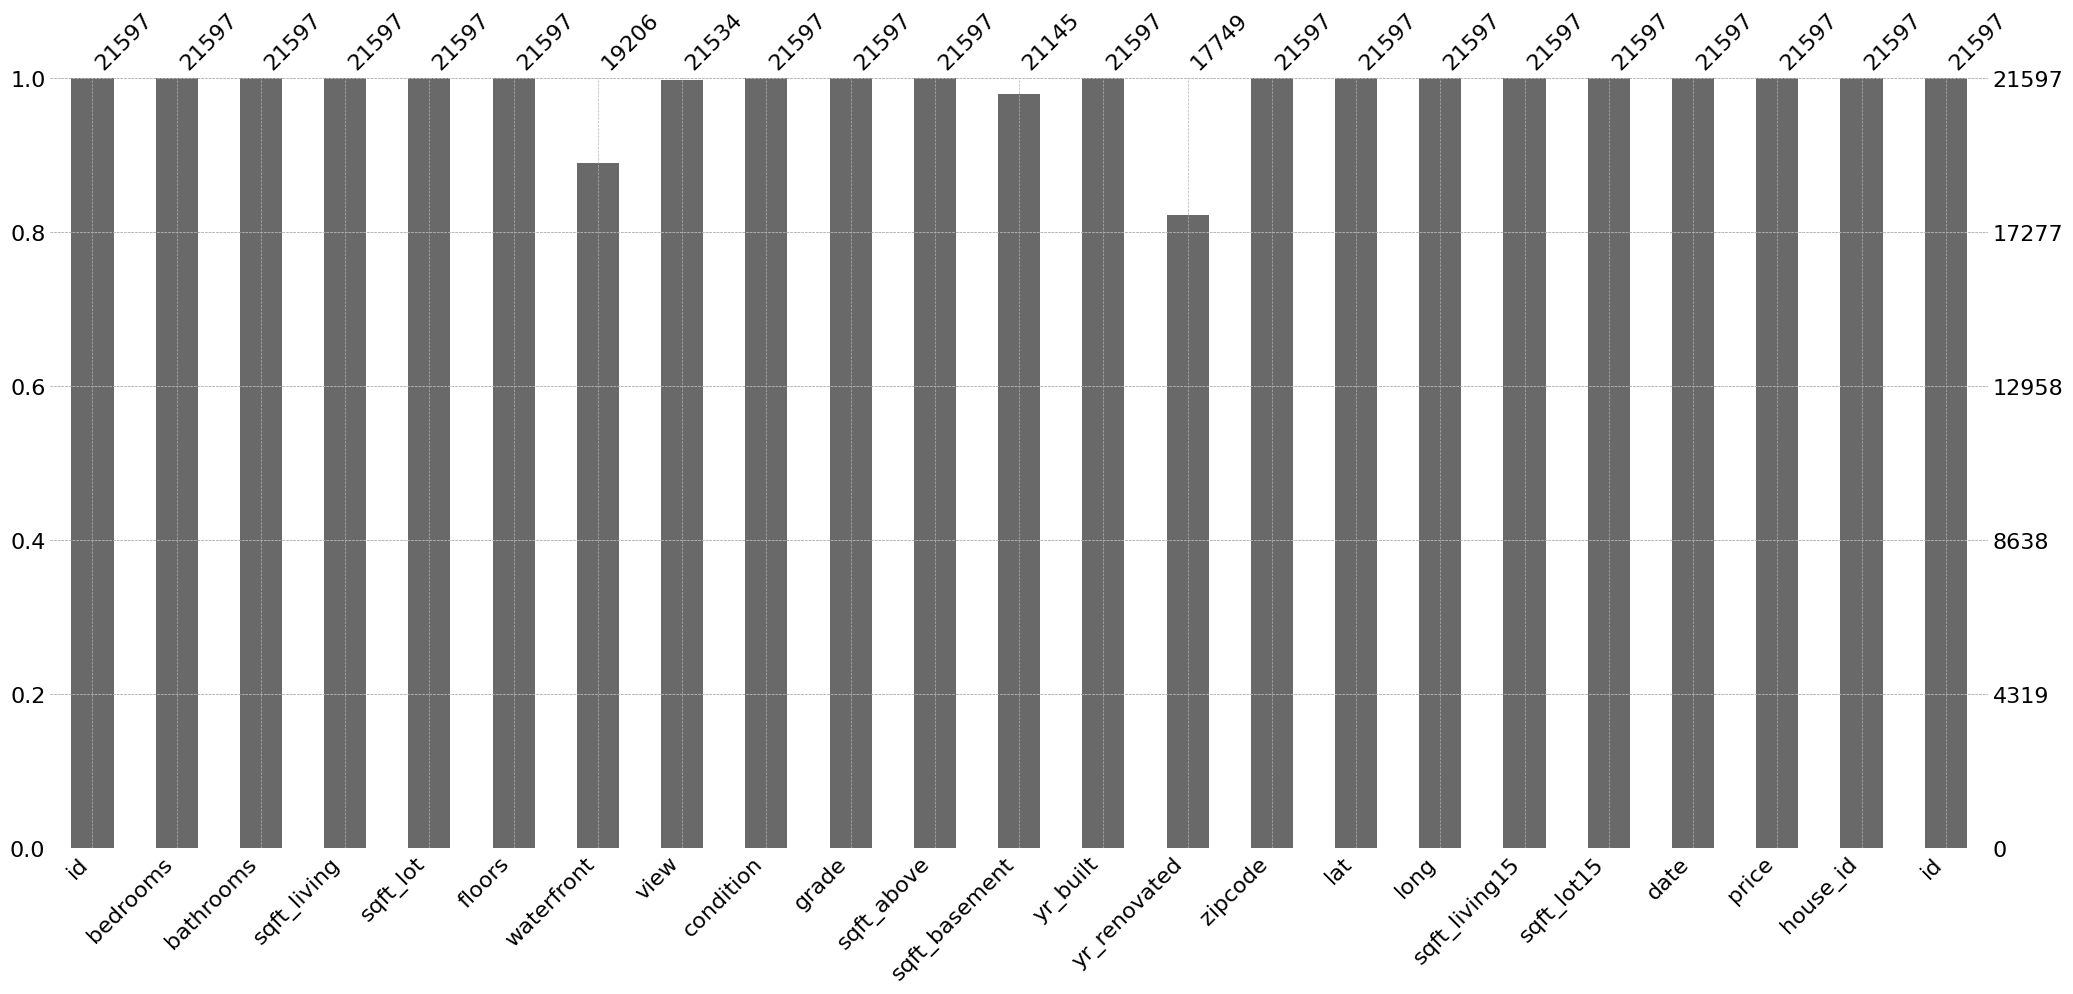

In [73]:
# plotting percentage of missing values per column
msno.bar(df)

We see that only two columns contain missing values: Less than 20 % of the data is missing in the column "yr_renovated" and 10 % of the data is missing in the column "waterfront"

DROPPING DATA

In [ ]:
print(f"numbers of rows : {df.shape[0]}")
print(
    f"missing values in yr_renovated : {round(df.yr_renovated.isna().sum() / df.yr_renovated.shape[0] * 100, 2)} %"
)
print(
    f"missing values in waterfront : {round(df.waterfront.isna().sum() / df.waterfront.shape[0] * 100, 2)} %"
)
print(
    f"missing values in data frame : {round(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2)} %"
)

numbers of rows : 21597
missing values in yr_renovated : 17.82 %
missing values in waterfront : 11.07 %
missing values in data frame : 3.24 %


We have 21597 rows and about less than a quarter of them have missing values in at least one column.

In [ ]:
# way 2: drop a row only if every value in it is missing

print(f"rows before dropna(how='all'): {df.shape[0]}")
df = df.dropna(how="all")

print(f"rows after dropna(how='all'): {df.shape[0]}")

rows before dropna(how='all'): 21597
rows after dropna(how='all'): 21597


In [ ]:
df.head()

,id,waterfront,view,condition,grade,yr_renovated,zipcode,price,date
0,7129300520,<NA>,0,3,7,0,98178,"$221,900.00",2014-10-13
1,6414100192,0,0,3,7,19910,98125,"$538,000.00",2014-12-09
2,5631500400,0,0,3,6,<NA>,98028,"$180,000.00",2015-02-25
3,2487200875,0,0,5,7,0,98136,"$604,000.00",2014-12-09
4,1954400510,0,0,3,8,0,98074,"$510,000.00",2015-02-18


In [ ]:
df['yr_renovated'].value_counts()

yr_renovated
0        17005
20140       73
20130       31
20030       31
20070       30
         ...  
19760        1
19460        1
19590        1
19340        1
19440        1
Name: count, Length: 70, dtype: Int64

In [ ]:
df["yr_renovated"] = df["yr_renovated"].where(df["yr_renovated"] == 0, df["yr_renovated"] / 10)

In [ ]:
cols = df.columns.tolist()
cols.insert(1, cols.pop(cols.index("date")))
df = df[cols]


We dont have any empty rows

In [104]:
df.head(20)

,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,...,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,date,price,house_id,id
0,7129300520,3.0,1.00,1180.0,5650.0,1.0,NaN,0.0,3,7,...,0.0,98178,47.5112,-122.257,1340.0,5650.0,2014-10-13,221900.0,7129300520,1
1,6414100192,3.0,2.25,2570.0,7242.0,2.0,0.0,0.0,3,7,...,19910.0,98125,47.7210,-122.319,1690.0,7639.0,2014-12-09,538000.0,6414100192,2
2,5631500400,2.0,1.00,770.0,10000.0,1.0,0.0,0.0,3,6,...,NaN,98028,47.7379,-122.233,2720.0,8062.0,2015-02-25,180000.0,5631500400,3
3,2487200875,4.0,3.00,1960.0,5000.0,1.0,0.0,0.0,5,7,...,0.0,98136,47.5208,-122.393,1360.0,5000.0,2014-12-09,604000.0,2487200875,4
4,1954400510,3.0,2.00,1680.0,8080.0,1.0,0.0,0.0,3,8,...,0.0,98074,47.6168,-122.045,1800.0,7503.0,2015-02-18,510000.0,1954400510,5
5,7237550310,4.0,4.50,5420.0,101930.0,1.0,0.0,0.0,3,11,...,0.0,98053,47.6561,-122.005,4760.0,101930.0,2014-05-12,1230000.0,7237550310,6
6,1321400060,3.0,2.25,1715.0,6819.0,2.0,0.0,0.0,3,7,...,0.0,98003,47.3097,-122.327,2238.0,6819.0,2014-06-27,257500.0,1321400060,7
7,2008000270,3.0,1.50,1060.0,9711.0,1.0,0.0,NaN,3,7,...,0.0,98198,47.4095,-122.315,1650.0,9711.0,2015-01-15,291850.0,2008000270,8
8,2414600126,3.0,1.00,1780.0,7470.0,1.0,0.0,0.0,3,7,...,0.0,98146,47.5123,-122.337,1780.0,8113.0,2015-04-15,229500.0,2414600126,9
9,3793500160,3.0,2.50,1890.0,6560.0,2.0,0.0,0.0,3,7,...,0.0,98038,47.3684,-122.031,2390.0,7570.0,2015-03-12,323000.0,3793500160,10


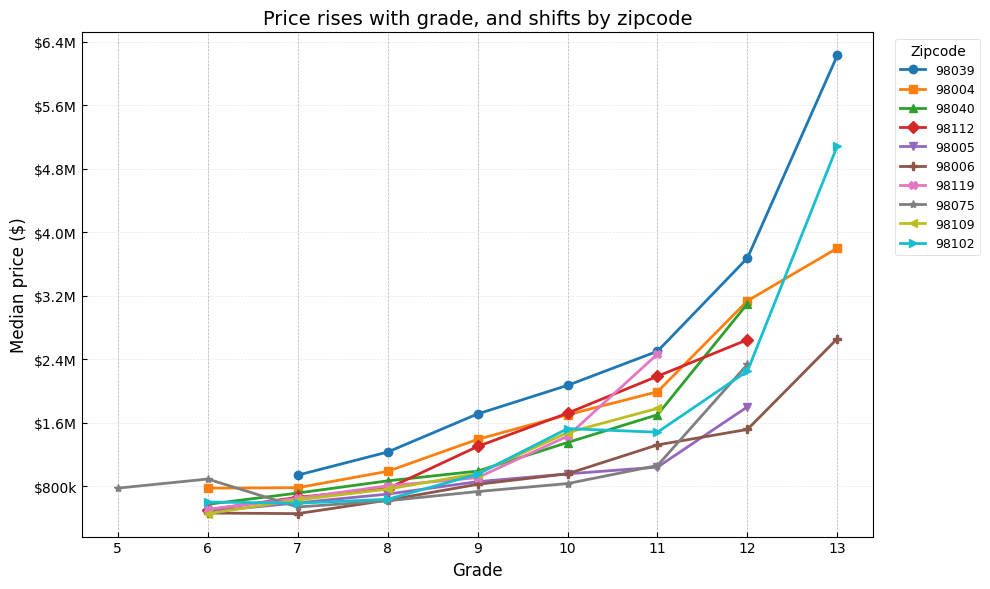

In [ ]:
import matplotlib.cm as cm
import matplotlib.ticker as mticker

colors = sns.color_palette("tab10", n_colors=len(top_zips))
markers = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">"]

fig, ax = plt.subplots(figsize=(10, 6))
for i, zc in enumerate(top_zips):
    sub = pivot.loc[zc]
    ax.plot(
        sub.index.astype(str),
        sub.values,
        marker=markers[i % len(markers)],
        color=colors[i],
        linewidth=2,
        markersize=6,
        label=zc,
    )

ax.set_title("Price rises with grade, and shifts by zipcode", fontsize=14)
ax.set_xlabel("Grade", fontsize=12)
ax.set_ylabel("Median price ($)", fontsize=12)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1_000_000:.1f}M" if x >= 1_000_000 else f"${x/1000:.0f}k"))
ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=8))

ax.tick_params(axis="both", labelsize=10)
ax.grid(True, axis="y", alpha=0.3)

ax.legend(title="Zipcode", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

In [103]:
import plotly.express as px

plot_df = pivot.loc[top_zips].reset_index().melt(id_vars="zipcode", var_name="grade", value_name="median_price")
plot_df = plot_df.dropna(subset=["median_price"])
plot_df["zipcode"] = plot_df["zipcode"].astype(str)


fig = px.line(
    plot_df,
    x="grade",
    y="median_price",
    color="zipcode",
    markers=True,
    category_orders={"zipcode": [str(z) for z in top_zips]},
    labels={"grade": "Grade", "median_price": "Median price ($)", "zipcode": "Zipcode"},
    title="Price rises with grade, and shifts by zipcode",
)

fig.update_traces(mode="lines+markers")
fig.update_layout(yaxis_tickformat="$,.0f")
fig.update_layout(
    yaxis_tickformat="$,.0f",
    width=1100,
    height=700,
)
fig.show()
fig.show()